# EXXA4 — Sequential Test: Transit Light Curve Classification

Author: Abdellah Elmlih | GSoC 2026, ML4Sci

Generate synthetic transit light curves with batman (Mandel & Agol 2002), then train a classical 1D-CNN and a hybrid quantum-classical classifier to detect planet transits. The quantum model uses a 6-qubit variational circuit via PennyLane.


## Setup


In [1]:
%%capture
# Install required packages (Colab-compatible)
!pip install batman-package pennylane pennylane-lightning torch torchmetrics scikit-learn matplotlib seaborn tqdm

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import batman
import pennylane as qml
from pennylane import numpy as pnp

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tqdm.auto import tqdm
import warnings, os, json, random
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"PennyLane: {qml.__version__}")

Device: cuda
PyTorch: 2.7.1+cu128
PennyLane: 0.44.0


## Data Generation

Transit curves simulated with `batman-package`. 8 physical parameters drawn from Kepler-informed priors. Noise added at multiple levels.


In [3]:

N_SAMPLES    = 6000        # Total samples (balanced 50/50)
N_POINTS     = 300         # Time steps per light curve
NOISE_LEVELS = [5e-4, 1e-3, 2e-3, 5e-3, 1e-2]  # Gaussian noise σ values

# Physical parameter ranges (informed by Kepler statistics)
PARAM_RANGES = {
    'rp_rs':  (0.01, 0.20),    # Planet-to-star radius ratio
    'a_rs':   (3.0, 50.0),     # Semi-major axis in stellar radii
    'inc':    (80.0, 90.0),    # Orbital inclination [deg]
    'ecc':    (0.0, 0.3),      # Eccentricity
    'omega':  (0.0, 360.0),    # Argument of periastron [deg]
    'period': (1.0, 50.0),     # Orbital period [days]
    'u1':     (0.1, 0.5),      # Quadratic limb-darkening coeff 1
    'u2':     (0.05, 0.35),    # Quadratic limb-darkening coeff 2
}

print("Configuration:")
print(f"  Total samples : {N_SAMPLES}")
print(f"  Time steps    : {N_POINTS}")
print(f"  Noise levels  : {NOISE_LEVELS}")

Configuration:
  Total samples : 6000
  Time steps    : 300
  Noise levels  : [0.0005, 0.001, 0.002, 0.005, 0.01]


In [4]:

def sample_transit_params():
    """Draw physical parameters from realistic priors."""
    pr = PARAM_RANGES
    params = {
        'rp_rs':  np.random.uniform(*pr['rp_rs']),
        'a_rs':   np.random.uniform(*pr['a_rs']),
        'inc':    np.random.uniform(*pr['inc']),
        'ecc':    np.random.uniform(*pr['ecc']),
        'omega':  np.random.uniform(*pr['omega']),
        'period': np.random.uniform(*pr['period']),
        'u1':     np.random.uniform(*pr['u1']),
        'u2':     np.random.uniform(*pr['u2']),
    }
    return params


def generate_transit_curve(params, n_points=N_POINTS):
    """Generate a single transit light curve using batman.
    
    Returns:
        t: time array centered on mid-transit
        flux: normalized flux array
    """
    # Time window centered on transit (±0.15 of a period)
    t0 = 0.0
    half_window = 0.15 * params['period']
    t = np.linspace(t0 - half_window, t0 + half_window, n_points)
    
    # batman parameter object
    bp = batman.TransitParams()
    bp.t0  = t0
    bp.per = params['period']
    bp.rp  = params['rp_rs']
    bp.a   = params['a_rs']
    bp.inc = params['inc']
    bp.ecc = params['ecc']
    bp.w   = params['omega']
    bp.u   = [params['u1'], params['u2']]
    bp.limb_dark = 'quadratic'
    
    m = batman.TransitModel(bp, t)
    flux = m.light_curve(bp)
    return t, flux


def add_realistic_noise(flux, noise_sigma):
    """Add white Gaussian noise + slow correlated (stellar) variability."""
    n = len(flux)
    # White noise
    white = np.random.normal(0, noise_sigma, n)
    # Correlated noise (slow sinusoidal stellar variability)
    freq = np.random.uniform(0.5, 3.0)
    phase = np.random.uniform(0, 2 * np.pi)
    amplitude = np.random.uniform(0.0, noise_sigma * 2)
    t_norm = np.linspace(0, 1, n)
    correlated = amplitude * np.sin(2 * np.pi * freq * t_norm + phase)
    return flux + white + correlated


def generate_flat_curve(n_points=N_POINTS):
    """Generate a non-transit (flat) light curve with realistic noise."""
    flux = np.ones(n_points)
    return flux


print("Transit generation functions defined.")

Transit generation functions defined.


In [5]:

def build_dataset(n_samples=N_SAMPLES, n_points=N_POINTS):
    """Generate balanced dataset of transit and non-transit light curves.
    
    Returns:
        X: (n_samples, n_points) array of light curves
        y: (n_samples,) binary labels
        metadata: list of dicts with physical params for each sample
    """
    n_pos = n_samples // 2
    n_neg = n_samples - n_pos
    
    X, y, metadata = [], [], []
    
    # --- Positive samples (with transit) ---
    print("Generating transit light curves...")
    for i in tqdm(range(n_pos), desc="Transit"):
        params = sample_transit_params()
        _, flux = generate_transit_curve(params, n_points)
        noise_sigma = np.random.choice(NOISE_LEVELS)
        flux_noisy = add_realistic_noise(flux, noise_sigma)
        X.append(flux_noisy)
        y.append(1)
        params['noise_sigma'] = noise_sigma
        params['label'] = 'transit'
        metadata.append(params)
    
    # --- Negative samples (no transit) ---
    print("Generating non-transit light curves...")
    for i in tqdm(range(n_neg), desc="Non-transit"):
        flux = generate_flat_curve(n_points)
        noise_sigma = np.random.choice(NOISE_LEVELS)
        flux_noisy = add_realistic_noise(flux, noise_sigma)
        X.append(flux_noisy)
        y.append(0)
        metadata.append({
            'noise_sigma': noise_sigma,
            'label': 'non-transit'
        })
    
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)
    
    # Shuffle
    idx = np.random.permutation(len(X))
    X, y = X[idx], y[idx]
    metadata = [metadata[i] for i in idx]
    
    return X, y, metadata


X_all, y_all, meta_all = build_dataset()
print(f"\nDataset shape: X={X_all.shape}, y={y_all.shape}")
print(f"Class balance : Transit={np.sum(y_all==1)}, Non-transit={np.sum(y_all==0)}")

Generating transit light curves...


Transit:   0%|          | 0/3000 [00:00<?, ?it/s]

Generating non-transit light curves...


Non-transit:   0%|          | 0/3000 [00:00<?, ?it/s]


Dataset shape: X=(6000, 300), y=(6000,)
Class balance : Transit=3000, Non-transit=3000


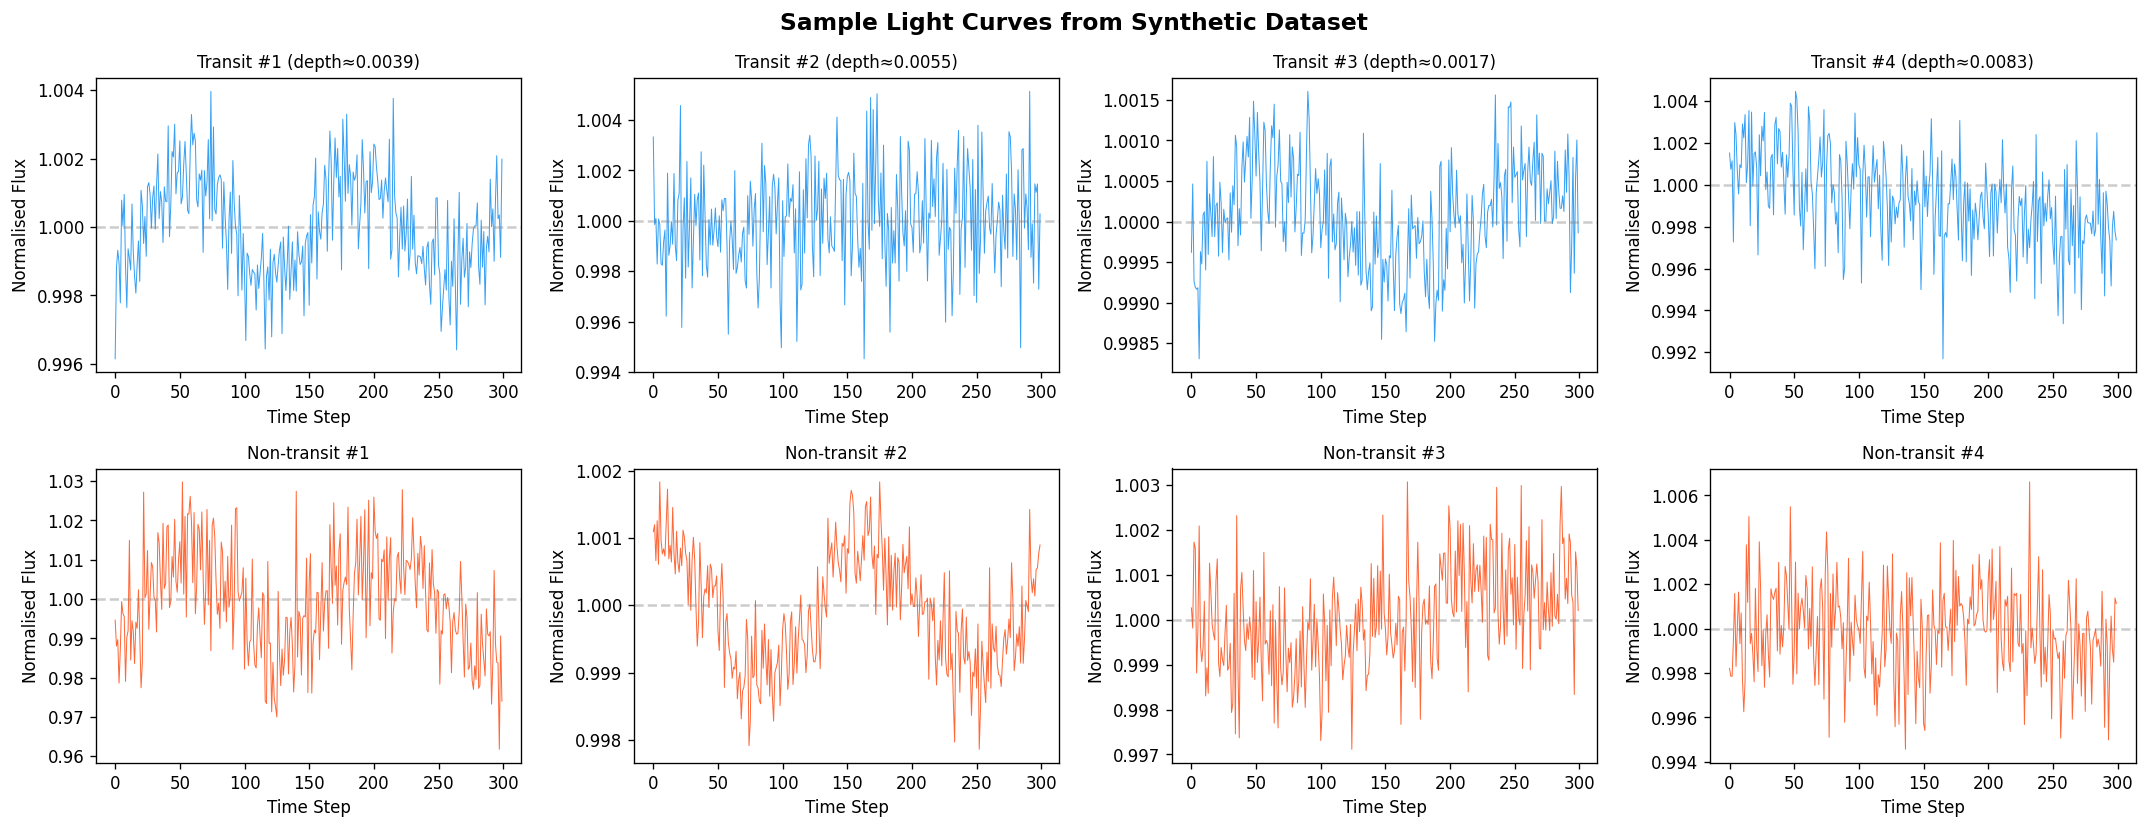

Saved: sample_lightcurves.png


In [6]:

fig, axes = plt.subplots(2, 4, figsize=(18, 7), dpi=120)
fig.suptitle('Sample Light Curves from Synthetic Dataset', fontsize=14, weight='bold')

# Transit examples
transit_idx = np.where(y_all == 1)[0][:4]
for i, idx in enumerate(transit_idx):
    ax = axes[0, i]
    ax.plot(X_all[idx], color='#2196F3', linewidth=0.6, alpha=0.9)
    depth = 1.0 - np.min(X_all[idx])
    ax.set_title(f'Transit #{i+1} (depth≈{depth:.4f})', fontsize=10)
    ax.set_ylabel('Normalised Flux')
    ax.set_xlabel('Time Step')
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)

# Non-transit examples
flat_idx = np.where(y_all == 0)[0][:4]
for i, idx in enumerate(flat_idx):
    ax = axes[1, i]
    ax.plot(X_all[idx], color='#FF5722', linewidth=0.6, alpha=0.9)
    ax.set_title(f'Non-transit #{i+1}', fontsize=10)
    ax.set_ylabel('Normalised Flux')
    ax.set_xlabel('Time Step')
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('sample_lightcurves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sample_lightcurves.png")

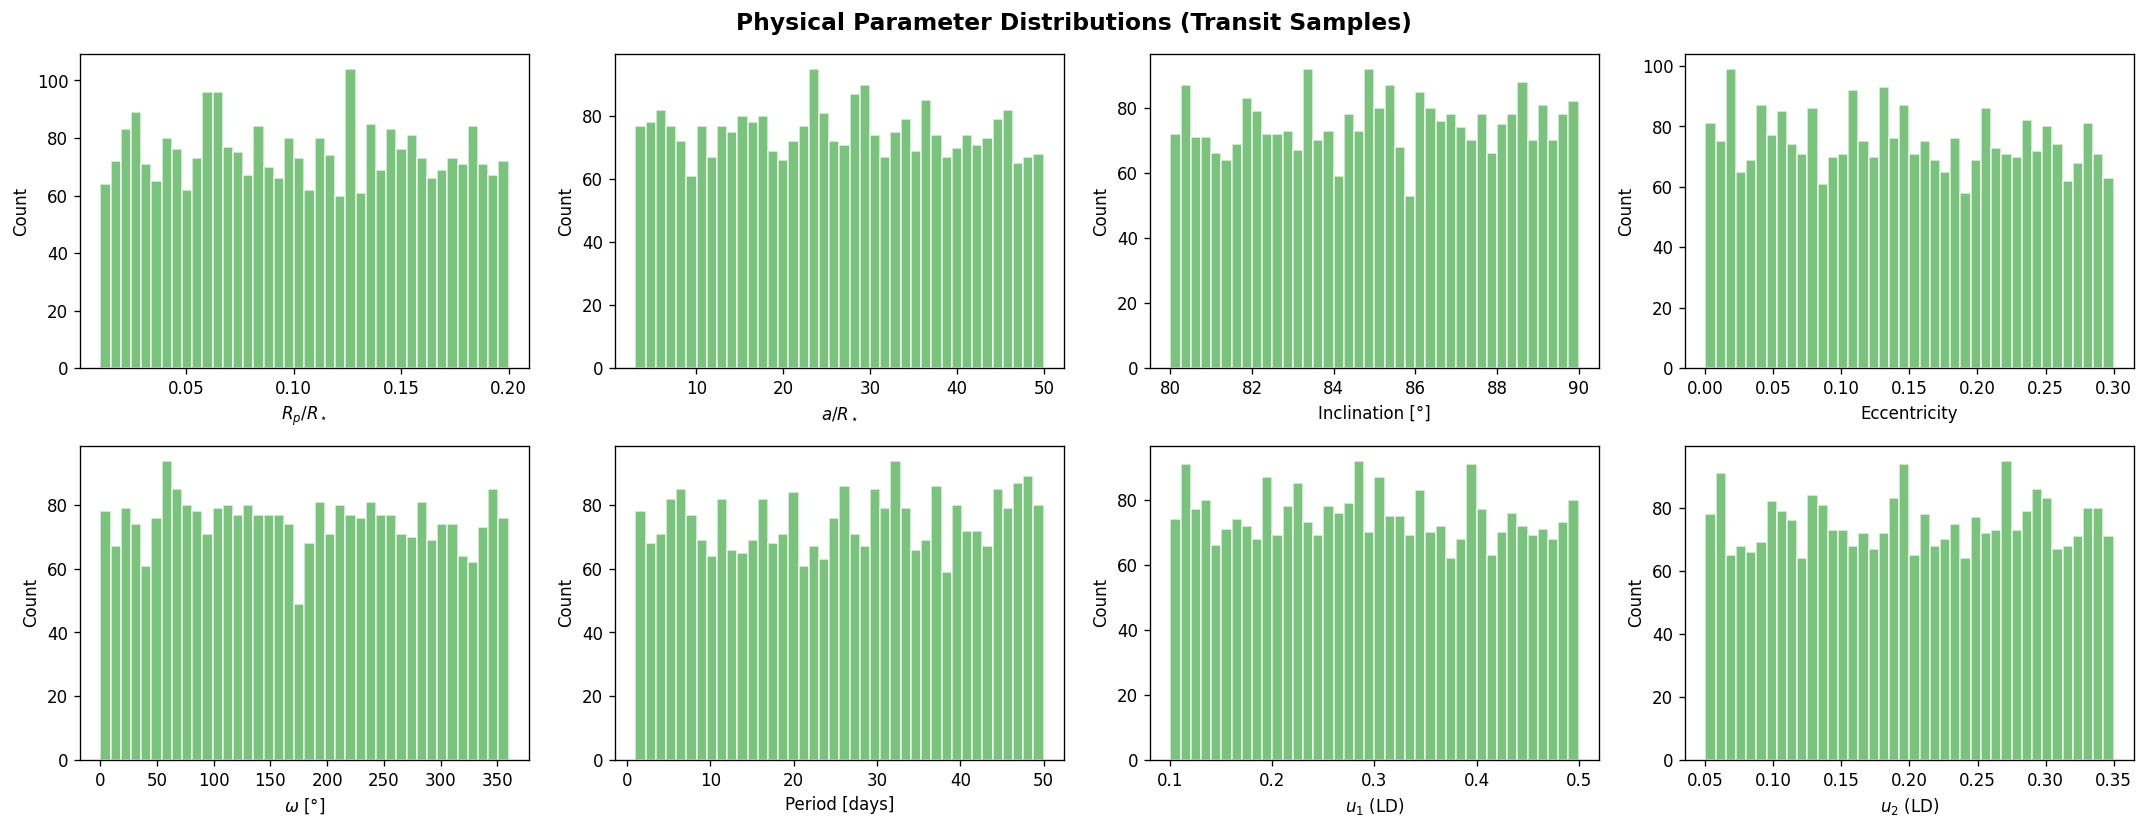

In [7]:

transit_meta = [m for m in meta_all if m['label'] == 'transit']

fig, axes = plt.subplots(2, 4, figsize=(18, 7), dpi=120)
fig.suptitle('Physical Parameter Distributions (Transit Samples)', fontsize=14, weight='bold')

param_keys = ['rp_rs', 'a_rs', 'inc', 'ecc', 'omega', 'period', 'u1', 'u2']
param_labels = [
    r'$R_p/R_\star$', r'$a/R_\star$', r'Inclination [°]', 
    'Eccentricity', r'$\omega$ [°]', 'Period [days]',
    r'$u_1$ (LD)', r'$u_2$ (LD)'
]

for i, (key, label) in enumerate(zip(param_keys, param_labels)):
    ax = axes[i // 4, i % 4]
    values = [m[key] for m in transit_meta]
    ax.hist(values, bins=40, color='#4CAF50', alpha=0.75, edgecolor='white')
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('param_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocessing & Splits


In [8]:

# Normalise: divide by median of the baseline (preserves transit depth!)
# Zero-mean/unit-variance normalization destroys the transit signal.
X_norm = np.copy(X_all)
for j in range(len(X_norm)):
    baseline = np.median(X_norm[j])
    if baseline > 0:
        X_norm[j] = X_norm[j] / baseline  # Transit depth is now 1 - dip
    # Subtract 1 so baseline is 0, dip is negative
    X_norm[j] = X_norm[j] - 1.0

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_norm, y_all, test_size=0.30, random_state=SEED, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {X_train.shape[0]} samples  (transit={np.sum(y_train==1)}, flat={np.sum(y_train==0)})')
print(f'Val   : {X_val.shape[0]} samples  (transit={np.sum(y_val==1)}, flat={np.sum(y_val==0)})')
print(f'Test  : {X_test.shape[0]} samples  (transit={np.sum(y_test==1)}, flat={np.sum(y_test==0)})')


Train : 4200 samples  (transit=2100, flat=2100)
Val   : 900 samples  (transit=450, flat=450)
Test  : 900 samples  (transit=450, flat=450)


In [9]:

BATCH_SIZE = 64

def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    """Create a DataLoader from numpy arrays."""
    # Shape: (N, 1, seq_len) for Conv1d
    Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
    yt = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(Xt, yt)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, y_train, shuffle=True)
val_loader   = make_loader(X_val, y_val, shuffle=False)
test_loader  = make_loader(X_test, y_test, shuffle=False)

print(f"Batches — Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Batches — Train: 66, Val: 15, Test: 15


## Classical CNN

1D residual CNN with GELU activations.


In [10]:

class ResBlock1D(nn.Module):
    """Residual block for 1D convolutions."""
    def __init__(self, channels, kernel_size=5, dropout=0.3):
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size, padding=pad),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.GELU()
    
    def forward(self, x):
        return self.act(x + self.block(x))


class TransitCNN(nn.Module):
    """1D-CNN classifier for transit detection.
    
    Architecture:
        Input (1, 300) → Conv blocks with increasing channels
        → Global Average Pooling → FC → sigmoid
    """
    def __init__(self, seq_len=N_POINTS, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (1, 300) → (32, 150)
            nn.Conv1d(1, 32, kernel_size=7, stride=1, padding=3),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.MaxPool1d(2),
            ResBlock1D(32, kernel_size=5),
            
            # Block 2: (32, 150) → (64, 75)
            nn.Conv1d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.MaxPool1d(2),
            ResBlock1D(64, kernel_size=5),
            
            # Block 3: (64, 75) → (128, 37)
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.MaxPool1d(2),
            ResBlock1D(128, kernel_size=3),
        )
        
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),       # (128, 1)
            nn.Flatten(),                   # (128,)
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(64, n_classes),
        )
    
    def forward(self, x):
        h = self.features(x)
        return self.classifier(h)
    
    def extract_features(self, x):
        """Return the 128-d feature vector before the classifier head."""
        h = self.features(x)
        h = nn.functional.adaptive_avg_pool1d(h, 1).squeeze(-1)
        return h


model_cnn = TransitCNN().to(DEVICE)
n_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)
print(f"TransitCNN — {n_params:,} trainable parameters")
print(model_cnn)

TransitCNN — 194,946 trainable parameters
TransitCNN(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ResBlock1D(
      (block): Sequential(
        (0): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Dropout(p=0.3, inplace=False)
        (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
        (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (act): GELU(approximate='none')
    )
    (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, 

In [11]:

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += X_batch.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        total_loss += loss.item() * X_batch.size(0)
        correct += (logits.argmax(1) == y_batch).sum().item()
        total += X_batch.size(0)
    return total_loss / total, correct / total


print("Training utilities ready.")

Training utilities ready.


In [12]:

N_EPOCHS_CNN = 40
LR_CNN = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=LR_CNN, weight_decay=1e-4)
scheduler_cnn = optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=N_EPOCHS_CNN)

history_cnn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

print(f"Training TransitCNN for {N_EPOCHS_CNN} epochs...\n")
for epoch in range(1, N_EPOCHS_CNN + 1):
    tr_loss, tr_acc = train_epoch(model_cnn, train_loader, criterion, optimizer_cnn, DEVICE)
    vl_loss, vl_acc = eval_epoch(model_cnn, val_loader, criterion, DEVICE)
    scheduler_cnn.step()
    
    history_cnn['train_loss'].append(tr_loss)
    history_cnn['val_loss'].append(vl_loss)
    history_cnn['train_acc'].append(tr_acc)
    history_cnn['val_acc'].append(vl_acc)
    
    # Save best model
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model_cnn.state_dict(), 'best_transit_cnn.pt')
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS_CNN}  "
              f"Train Loss={tr_loss:.4f}  Acc={tr_acc:.4f}  │  "
              f"Val Loss={vl_loss:.4f}  Acc={vl_acc:.4f}")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# Load best weights
model_cnn.load_state_dict(torch.load('best_transit_cnn.pt'))
print("Loaded best model weights.")

Training TransitCNN for 40 epochs...

Epoch   1/40  Train Loss=0.6712  Acc=0.5681  │  Val Loss=0.6854  Acc=0.5356
Epoch   5/40  Train Loss=0.6326  Acc=0.5957  │  Val Loss=0.6392  Acc=0.5856
Epoch  10/40  Train Loss=0.6281  Acc=0.6000  │  Val Loss=0.6437  Acc=0.5856
Epoch  15/40  Train Loss=0.6219  Acc=0.6069  │  Val Loss=0.6191  Acc=0.6089
Epoch  20/40  Train Loss=0.6259  Acc=0.6052  │  Val Loss=0.6266  Acc=0.5967
Epoch  25/40  Train Loss=0.6144  Acc=0.6133  │  Val Loss=0.6209  Acc=0.6033
Epoch  30/40  Train Loss=0.6123  Acc=0.6245  │  Val Loss=0.6181  Acc=0.6022
Epoch  35/40  Train Loss=0.6076  Acc=0.6281  │  Val Loss=0.6182  Acc=0.6044
Epoch  40/40  Train Loss=0.6075  Acc=0.6350  │  Val Loss=0.6196  Acc=0.6033

Best validation accuracy: 0.6144
Loaded best model weights.


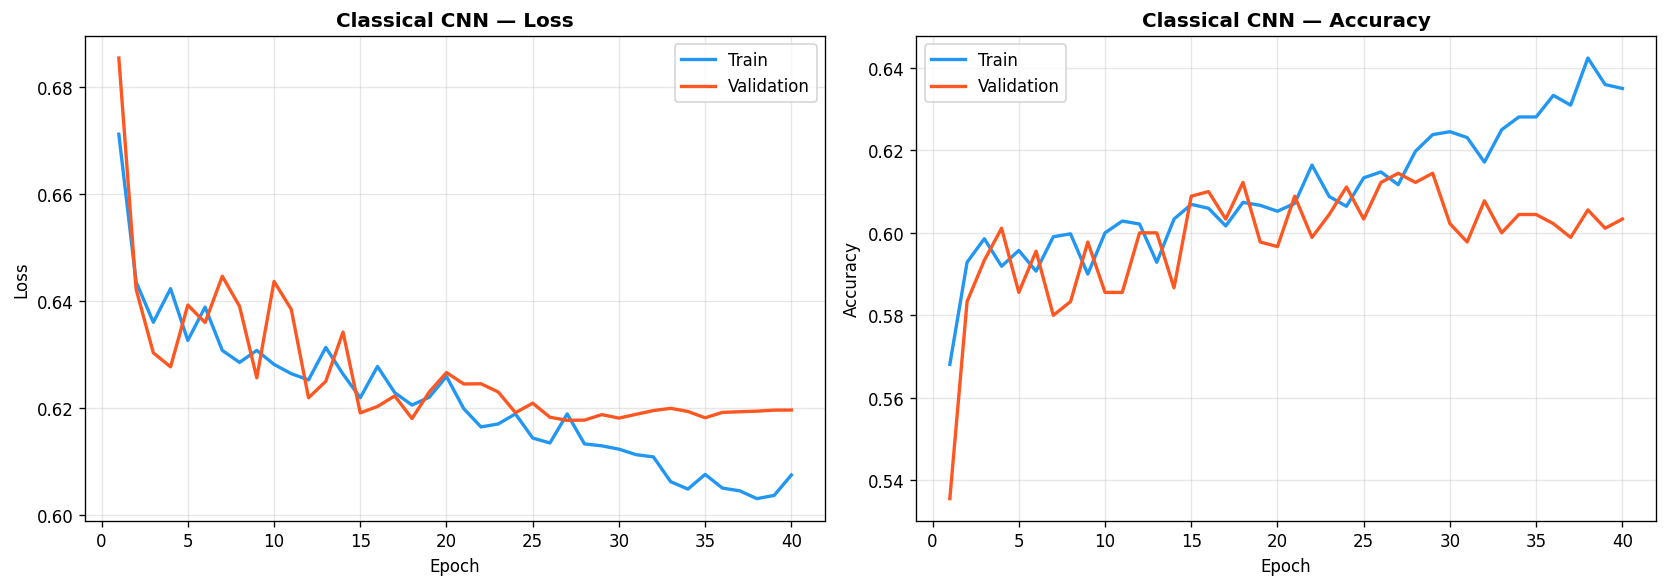

In [13]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

epochs_range = range(1, N_EPOCHS_CNN + 1)

ax1.plot(epochs_range, history_cnn['train_loss'], label='Train', color='#2196F3', linewidth=2)
ax1.plot(epochs_range, history_cnn['val_loss'], label='Validation', color='#FF5722', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Classical CNN — Loss', weight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history_cnn['train_acc'], label='Train', color='#2196F3', linewidth=2)
ax2.plot(epochs_range, history_cnn['val_acc'], label='Validation', color='#FF5722', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Classical CNN — Accuracy', weight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Hybrid Quantum Classifier

Classical CNN backbone compresses the light curve, then a 6-qubit VQC with angle encoding and CNOT entanglement does the classification.


In [14]:

N_QUBITS = 6          # Number of qubits
N_QLAYERS = 4         # Number of variational layers
Q_DEVICE = 'default.qubit'

dev = qml.device(Q_DEVICE, wires=N_QUBITS)

@qml.qnode(dev, interface='torch', diff_method='backprop')
def quantum_circuit(inputs, weights):
    """Variational Quantum Circuit for classification.
    
    Args:
        inputs: (N_QUBITS,) tensor — angle-encoded features
        weights: (N_QLAYERS, N_QUBITS, 3) tensor — variational params
    
    Returns:
        Expectation values of PauliZ on first 2 qubits (for 2-class)
    """
    # Angle encoding
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)
    
    # Variational layers with strong entanglement
    for layer in range(N_QLAYERS):
        # Parameterised rotations
        for i in range(N_QUBITS):
            qml.Rot(weights[layer, i, 0],
                     weights[layer, i, 1],
                     weights[layer, i, 2], wires=i)
        # Entangling CNOT ring
        for i in range(N_QUBITS):
            qml.CNOT(wires=[i, (i + 1) % N_QUBITS])
    
    # Measure first 2 qubits for binary classification
    return [qml.expval(qml.PauliZ(i)) for i in range(2)]


# Visualise the circuit
print("Quantum Circuit:")
dummy_in = torch.zeros(N_QUBITS)
dummy_w  = torch.zeros(N_QLAYERS, N_QUBITS, 3)
print(qml.draw(quantum_circuit)(dummy_in, dummy_w))

Quantum Circuit:
0: ──RY(0.00)──RZ(0.00)──Rot(0.00,0.00,0.00)─╭●─────────────╭X──Rot(0.00,0.00,0.00)─╭●───────── ···
1: ──RY(0.00)──RZ(0.00)──Rot(0.00,0.00,0.00)─╰X─╭●──────────│───Rot(0.00,0.00,0.00)─╰X─╭●────── ···
2: ──RY(0.00)──RZ(0.00)──Rot(0.00,0.00,0.00)────╰X─╭●───────│───Rot(0.00,0.00,0.00)────╰X─╭●─── ···
3: ──RY(0.00)──RZ(0.00)──Rot(0.00,0.00,0.00)───────╰X─╭●────│───Rot(0.00,0.00,0.00)───────╰X─╭● ···
4: ──RY(0.00)──RZ(0.00)──Rot(0.00,0.00,0.00)──────────╰X─╭●─│───Rot(0.00,0.00,0.00)──────────╰X ···
5: ──RY(0.00)──RZ(0.00)──Rot(0.00,0.00,0.00)─────────────╰X─╰●──Rot(0.00,0.00,0.00)──────────── ···

0: ··· ────╭X──Rot(0.00,0.00,0.00)─╭●─────────────╭X──Rot(0.00,0.00,0.00)─╭●─────────────╭X─┤  <Z>
1: ··· ────│───Rot(0.00,0.00,0.00)─╰X─╭●──────────│───Rot(0.00,0.00,0.00)─╰X─╭●──────────│──┤  <Z>
2: ··· ────│───Rot(0.00,0.00,0.00)────╰X─╭●───────│───Rot(0.00,0.00,0.00)────╰X─╭●───────│──┤     
3: ··· ────│───Rot(0.00,0.00,0.00)───────╰X─╭●────│───Rot(0.00,0.00,0.00)───────╰X─╭●

In [15]:

class QuantumLayer(nn.Module):
    """Wraps the PennyLane QNode as a PyTorch layer."""
    def __init__(self, n_qubits=N_QUBITS, n_qlayers=N_QLAYERS):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_qlayers = n_qlayers
        # Variational parameters
        weight_shape = (n_qlayers, n_qubits, 3)
        self.weights = nn.Parameter(0.01 * torch.randn(*weight_shape))
    
    def forward(self, x):
        """x: (batch, n_qubits) → (batch, 2)"""
        batch_size = x.shape[0]
        results = []
        for i in range(batch_size):
            result = quantum_circuit(x[i], self.weights)
            results.append(torch.stack(result))
        return torch.stack(results).float()  # PennyLane returns float64, PyTorch needs float32


class HybridQuantumClassifier(nn.Module):
    """Classical feature extractor + Quantum classification head.
    
    Architecture:
        Input (1, 300) → Classical CNN → FC(128 → n_qubits) → VQC → 2 logits
    """
    def __init__(self, seq_len=N_POINTS, n_qubits=N_QUBITS):
        super().__init__()
        # Lightweight classical backbone
        self.backbone = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(16),
            nn.GELU(),
            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
        )
        
        # Classical → quantum bridge
        self.pre_quantum = nn.Sequential(
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, n_qubits),
            nn.Tanh(),  # Bound inputs to [-1, 1] for angle encoding
        )
        
        # Scale to [0, π] for angle encoding
        self.input_scaling = nn.Parameter(torch.ones(n_qubits) * np.pi)
        
        # Quantum layer
        self.quantum = QuantumLayer(n_qubits=n_qubits)
        
        # Post-processing
        self.post_quantum = nn.Sequential(
            nn.Linear(2, 2),  # Map expectation values to class logits
        )
    
    def forward(self, x):
        h = self.backbone(x)
        h = self.pre_quantum(h)
        h = h * self.input_scaling  # Scale for angle encoding
        h = self.quantum(h)
        return self.post_quantum(h)


model_hybrid = HybridQuantumClassifier().to('cpu')  # Quantum sim on CPU
n_params_h = sum(p.numel() for p in model_hybrid.parameters() if p.requires_grad)
print(f"HybridQuantumClassifier — {n_params_h:,} trainable parameters")
print(f"  Classical: {sum(p.numel() for n, p in model_hybrid.named_parameters() if 'quantum' not in n):,}")
print(f"  Quantum:   {sum(p.numel() for n, p in model_hybrid.named_parameters() if 'quantum' in n):,}")

HybridQuantumClassifier — 11,514 trainable parameters
  Classical: 9,158
  Quantum:   2,356


In [16]:

# Use smaller subset for quantum training (simulation is slow)
N_QUANTUM_TRAIN = 1200
N_QUANTUM_VAL   = 300

X_qtrain = X_norm[:N_QUANTUM_TRAIN]
y_qtrain = y_all[:N_QUANTUM_TRAIN]
X_qval   = X_norm[N_QUANTUM_TRAIN:N_QUANTUM_TRAIN + N_QUANTUM_VAL]
y_qval   = y_all[N_QUANTUM_TRAIN:N_QUANTUM_TRAIN + N_QUANTUM_VAL]

BATCH_SIZE_Q = 16
qtrain_loader = make_loader(X_qtrain, y_qtrain, batch_size=BATCH_SIZE_Q, shuffle=True)
qval_loader   = make_loader(X_qval, y_qval, batch_size=BATCH_SIZE_Q, shuffle=False)

N_EPOCHS_Q = 20
LR_Q = 5e-3

optimizer_q = optim.Adam(model_hybrid.parameters(), lr=LR_Q)
scheduler_q = optim.lr_scheduler.CosineAnnealingLR(optimizer_q, T_max=N_EPOCHS_Q)

history_q = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc_q = 0.0

print(f"Training HybridQuantumClassifier for {N_EPOCHS_Q} epochs on {N_QUANTUM_TRAIN} samples...")
print(f"(Quantum simulation — expect ~1-3 min/epoch on CPU)\n")

for epoch in range(1, N_EPOCHS_Q + 1):
    # Force CPU for quantum
    tr_loss, tr_acc = train_epoch(model_hybrid, qtrain_loader, criterion, optimizer_q, 'cpu')
    vl_loss, vl_acc = eval_epoch(model_hybrid, qval_loader, criterion, 'cpu')
    scheduler_q.step()
    
    history_q['train_loss'].append(tr_loss)
    history_q['val_loss'].append(vl_loss)
    history_q['train_acc'].append(tr_acc)
    history_q['val_acc'].append(vl_acc)
    
    if vl_acc > best_val_acc_q:
        best_val_acc_q = vl_acc
        torch.save(model_hybrid.state_dict(), 'best_hybrid_quantum.pt')
    
    print(f"Epoch {epoch:2d}/{N_EPOCHS_Q}  "
          f"Train Loss={tr_loss:.4f}  Acc={tr_acc:.4f}  │  "
          f"Val Loss={vl_loss:.4f}  Acc={vl_acc:.4f}")

print(f"\nBest quantum validation accuracy: {best_val_acc_q:.4f}")
model_hybrid.load_state_dict(torch.load('best_hybrid_quantum.pt'))

Training HybridQuantumClassifier for 20 epochs on 1200 samples...
(Quantum simulation — expect ~1-3 min/epoch on CPU)

Epoch  1/20  Train Loss=0.7020  Acc=0.5117  │  Val Loss=0.6953  Acc=0.4933
Epoch  2/20  Train Loss=0.6940  Acc=0.5342  │  Val Loss=0.6794  Acc=0.5767
Epoch  3/20  Train Loss=0.6867  Acc=0.5500  │  Val Loss=0.6875  Acc=0.5400
Epoch  4/20  Train Loss=0.6848  Acc=0.5592  │  Val Loss=0.7477  Acc=0.4867
Epoch  5/20  Train Loss=0.6872  Acc=0.5475  │  Val Loss=0.6917  Acc=0.5667
Epoch  6/20  Train Loss=0.6814  Acc=0.5508  │  Val Loss=0.7000  Acc=0.4600
Epoch  7/20  Train Loss=0.6738  Acc=0.5683  │  Val Loss=0.6893  Acc=0.5367
Epoch  8/20  Train Loss=0.6638  Acc=0.5775  │  Val Loss=0.8274  Acc=0.5033
Epoch  9/20  Train Loss=0.6638  Acc=0.5683  │  Val Loss=0.6842  Acc=0.5600
Epoch 10/20  Train Loss=0.6614  Acc=0.5708  │  Val Loss=0.6999  Acc=0.5033
Epoch 11/20  Train Loss=0.6709  Acc=0.5525  │  Val Loss=0.6526  Acc=0.6067
Epoch 12/20  Train Loss=0.6569  Acc=0.5733  │  Val Loss=

<All keys matched successfully>

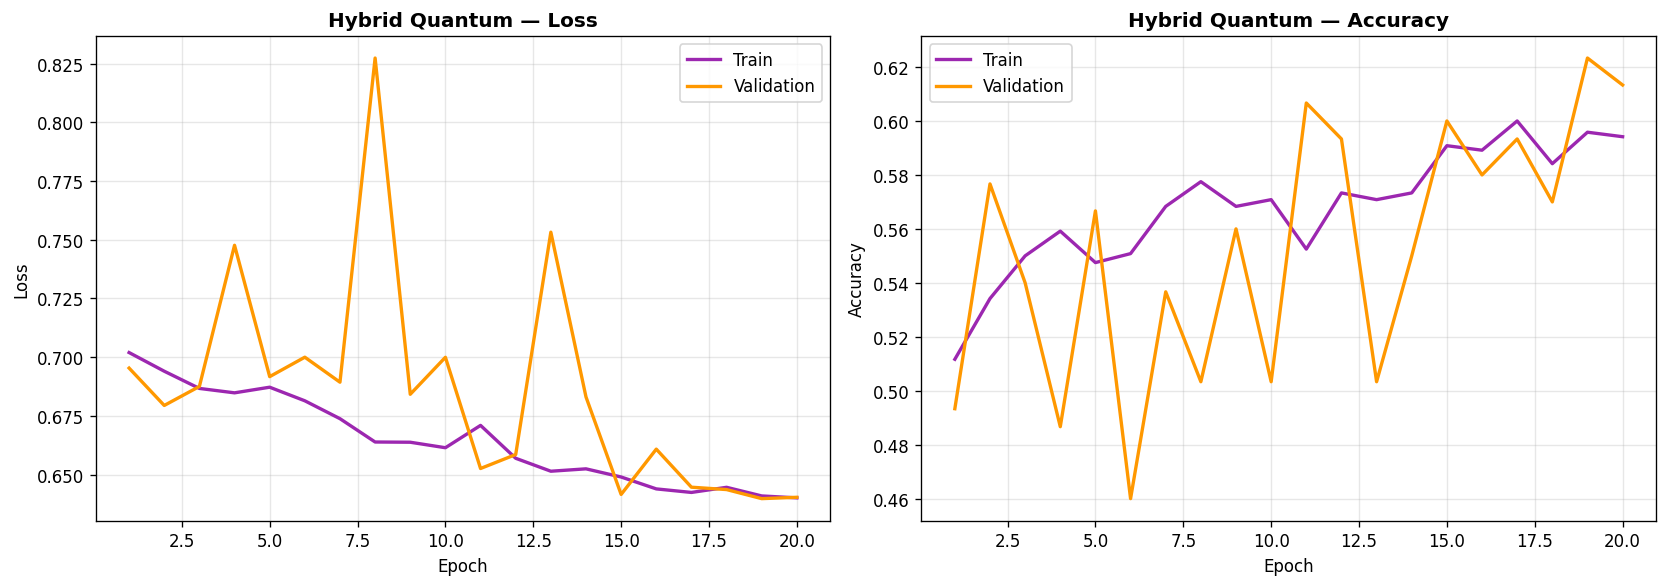

In [17]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

epochs_q = range(1, N_EPOCHS_Q + 1)

ax1.plot(epochs_q, history_q['train_loss'], label='Train', color='#9C27B0', linewidth=2)
ax1.plot(epochs_q, history_q['val_loss'], label='Validation', color='#FF9800', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Hybrid Quantum — Loss', weight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_q, history_q['train_acc'], label='Train', color='#9C27B0', linewidth=2)
ax2.plot(epochs_q, history_q['val_acc'], label='Validation', color='#FF9800', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Hybrid Quantum — Accuracy', weight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('hybrid_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation

ROC/AUC, precision-recall, confusion matrices. Both models compared.


In [18]:

@torch.no_grad()
def get_predictions(model, loader, device):
    """Get predictions and probabilities from a model."""
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.numpy())
    return (
        np.concatenate(all_probs),
        np.concatenate(all_preds),
        np.concatenate(all_labels)
    )


# Classical CNN on full test set
probs_cnn, preds_cnn, labels_test = get_predictions(model_cnn, test_loader, DEVICE)

# Hybrid quantum on subset (use same test data but on CPU)
qtest_loader = make_loader(X_test, y_test, batch_size=BATCH_SIZE_Q, shuffle=False)
probs_hybrid, preds_hybrid, _ = get_predictions(model_hybrid, qtest_loader, 'cpu')

print(f"CNN test accuracy    : {np.mean(preds_cnn == labels_test):.4f}")
print(f"Hybrid test accuracy : {np.mean(preds_hybrid == labels_test):.4f}")

CNN test accuracy    : 0.6211
Hybrid test accuracy : 0.5967


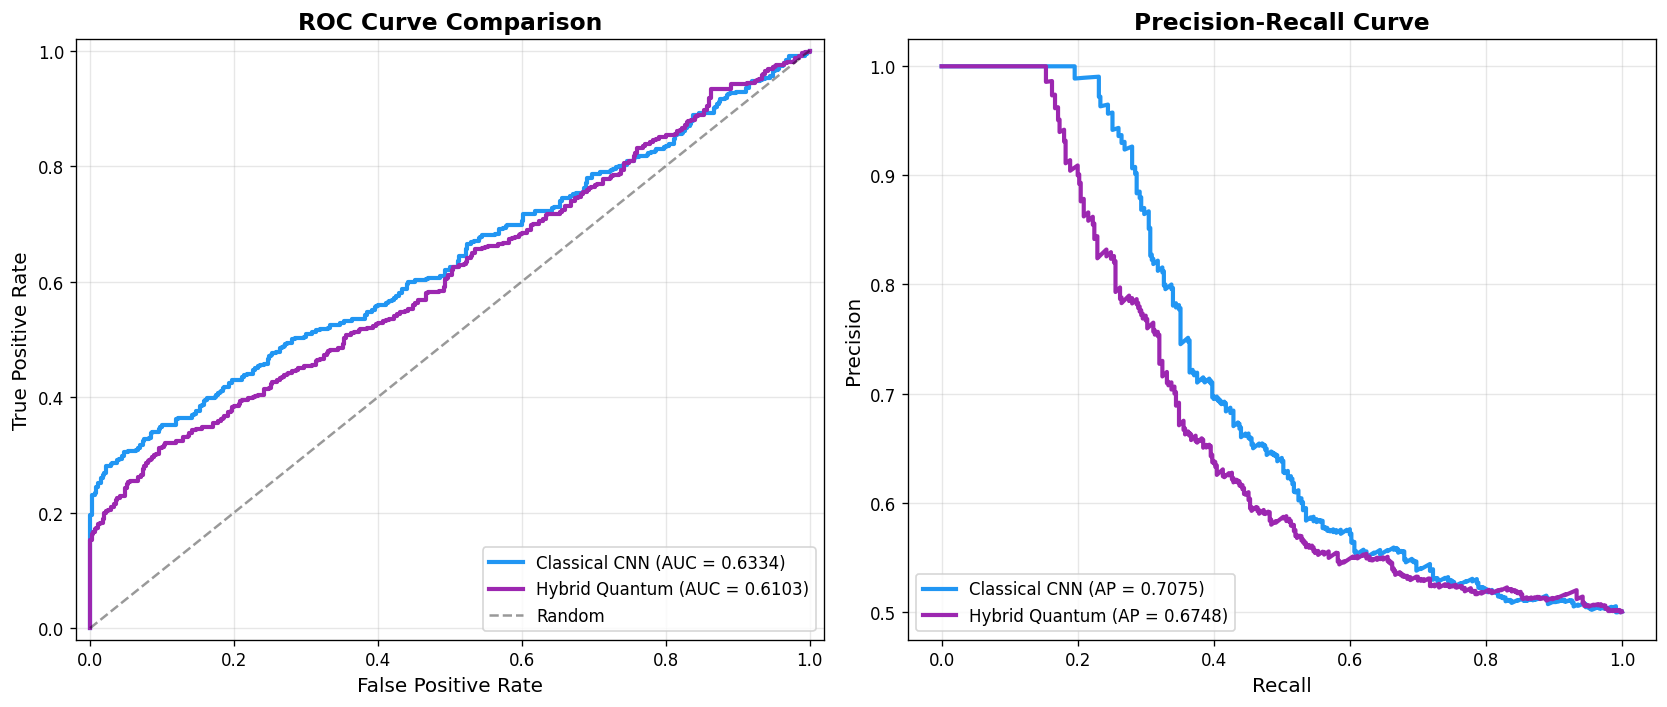


  Classical CNN  — AUC: 0.6334 | AP: 0.7075
  Hybrid Quantum — AUC: 0.6103 | AP: 0.6748


In [19]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

# --- ROC ---
fpr_cnn, tpr_cnn, _ = roc_curve(labels_test, probs_cnn[:, 1])
auc_cnn = auc(fpr_cnn, tpr_cnn)

fpr_hyb, tpr_hyb, _ = roc_curve(labels_test, probs_hybrid[:, 1])
auc_hyb = auc(fpr_hyb, tpr_hyb)

ax1.plot(fpr_cnn, tpr_cnn, color='#2196F3', linewidth=2.5,
         label=f'Classical CNN (AUC = {auc_cnn:.4f})')
ax1.plot(fpr_hyb, tpr_hyb, color='#9C27B0', linewidth=2.5,
         label=f'Hybrid Quantum (AUC = {auc_hyb:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve Comparison', fontsize=14, weight='bold')
ax1.legend(fontsize=10, loc='lower right')
ax1.grid(alpha=0.3)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])

# --- Precision-Recall ---
prec_cnn, rec_cnn, _ = precision_recall_curve(labels_test, probs_cnn[:, 1])
ap_cnn = average_precision_score(labels_test, probs_cnn[:, 1])

prec_hyb, rec_hyb, _ = precision_recall_curve(labels_test, probs_hybrid[:, 1])
ap_hyb = average_precision_score(labels_test, probs_hybrid[:, 1])

ax2.plot(rec_cnn, prec_cnn, color='#2196F3', linewidth=2.5,
         label=f'Classical CNN (AP = {ap_cnn:.4f})')
ax2.plot(rec_hyb, prec_hyb, color='#9C27B0', linewidth=2.5,
         label=f'Hybrid Quantum (AP = {ap_hyb:.4f})')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=14, weight='bold')
ax2.legend(fontsize=10, loc='lower left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print(f"  Classical CNN  — AUC: {auc_cnn:.4f} | AP: {ap_cnn:.4f}")
print(f"  Hybrid Quantum — AUC: {auc_hyb:.4f} | AP: {ap_hyb:.4f}")
print(f"{'='*50}")

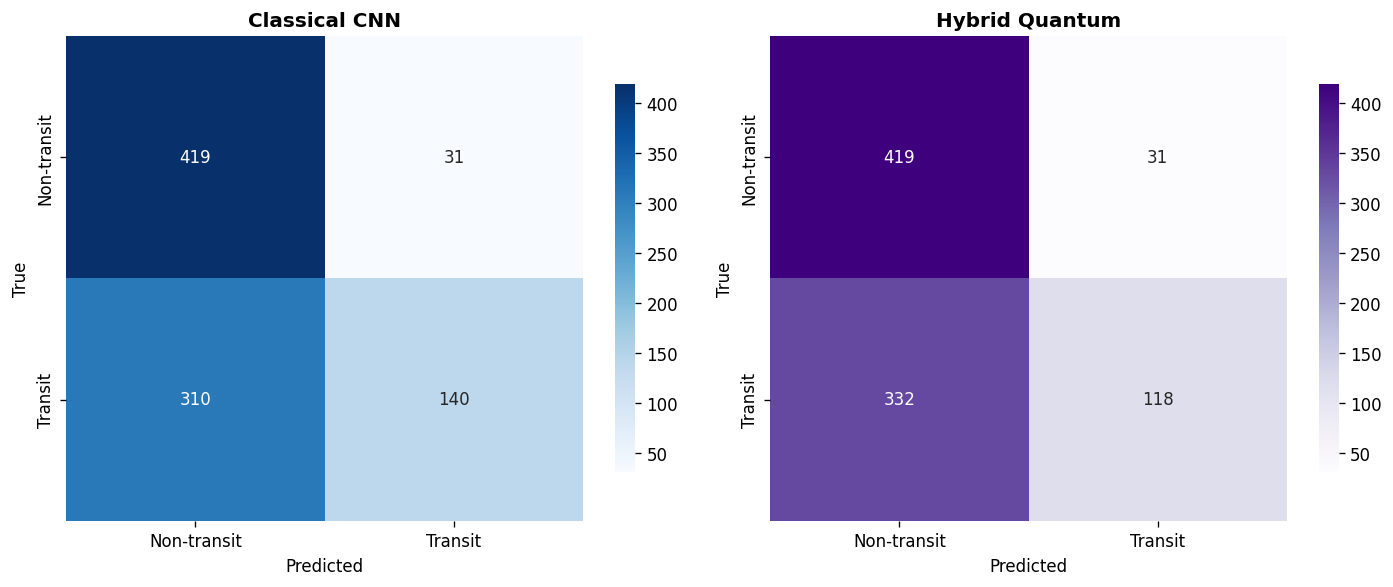

In [20]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

for ax, preds, name, color in [
    (ax1, preds_cnn, 'Classical CNN', 'Blues'),
    (ax2, preds_hybrid, 'Hybrid Quantum', 'Purples')
]:
    cm = confusion_matrix(labels_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=ax,
                xticklabels=['Non-transit', 'Transit'],
                yticklabels=['Non-transit', 'Transit'],
                cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name}', weight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:

print("=" * 55)
print("CLASSICAL CNN — Classification Report")
print("=" * 55)
print(classification_report(labels_test, preds_cnn,
                            target_names=['Non-transit', 'Transit']))

print("\n" + "=" * 55)
print("HYBRID QUANTUM — Classification Report")
print("=" * 55)
print(classification_report(labels_test, preds_hybrid,
                            target_names=['Non-transit', 'Transit']))

CLASSICAL CNN — Classification Report
              precision    recall  f1-score   support

 Non-transit       0.57      0.93      0.71       450
     Transit       0.82      0.31      0.45       450

    accuracy                           0.62       900
   macro avg       0.70      0.62      0.58       900
weighted avg       0.70      0.62      0.58       900


HYBRID QUANTUM — Classification Report
              precision    recall  f1-score   support

 Non-transit       0.56      0.93      0.70       450
     Transit       0.79      0.26      0.39       450

    accuracy                           0.60       900
   macro avg       0.67      0.60      0.55       900
weighted avg       0.67      0.60      0.55       900



## Noise Robustness


In [22]:

STRESS_NOISE_LEVELS = [1e-4, 5e-4, 1e-3, 3e-3, 5e-3, 1e-2, 2e-2, 5e-2]
N_STRESS = 200  # Per noise level

stress_results = {'noise': [], 'auc_cnn': [], 'auc_hybrid': []}

print("Running noise-level stress test...")
for noise_sigma in tqdm(STRESS_NOISE_LEVELS, desc="Noise levels"):
    X_stress, y_stress = [], []
    
    for _ in range(N_STRESS // 2):
        # Transit
        params = sample_transit_params()
        _, flux = generate_transit_curve(params)
        flux_n = add_realistic_noise(flux, noise_sigma)
        baseline = np.median(flux_n); flux_n = flux_n / (baseline + 1e-8) - 1.0
        X_stress.append(flux_n)
        y_stress.append(1)
        
        # Flat
        flux_f = add_realistic_noise(np.ones(N_POINTS), noise_sigma)
        baseline = np.median(flux_f); flux_f = flux_f / (baseline + 1e-8) - 1.0
        X_stress.append(flux_f)
        y_stress.append(0)
    
    X_s = np.array(X_stress, dtype=np.float32)
    y_s = np.array(y_stress, dtype=np.int64)
    loader_s = make_loader(X_s, y_s, batch_size=32, shuffle=False)
    
    # CNN
    probs_c, _, labels_s = get_predictions(model_cnn, loader_s, DEVICE)
    fpr_c, tpr_c, _ = roc_curve(labels_s, probs_c[:, 1])
    auc_c = auc(fpr_c, tpr_c)
    
    # Hybrid
    loader_sq = make_loader(X_s, y_s, batch_size=BATCH_SIZE_Q, shuffle=False)
    probs_h, _, _ = get_predictions(model_hybrid, loader_sq, 'cpu')
    fpr_h, tpr_h, _ = roc_curve(labels_s, probs_h[:, 1])
    auc_h = auc(fpr_h, tpr_h)
    
    stress_results['noise'].append(noise_sigma)
    stress_results['auc_cnn'].append(auc_c)
    stress_results['auc_hybrid'].append(auc_h)
    print(f"  σ={noise_sigma:.0e} → CNN AUC={auc_c:.4f}, Hybrid AUC={auc_h:.4f}")

Running noise-level stress test...


Noise levels:   0%|          | 0/8 [00:00<?, ?it/s]

  σ=1e-04 → CNN AUC=0.6780, Hybrid AUC=0.6746
  σ=5e-04 → CNN AUC=0.7364, Hybrid AUC=0.6800
  σ=1e-03 → CNN AUC=0.7212, Hybrid AUC=0.6846
  σ=3e-03 → CNN AUC=0.5568, Hybrid AUC=0.5400
  σ=5e-03 → CNN AUC=0.6505, Hybrid AUC=0.6000
  σ=1e-02 → CNN AUC=0.5217, Hybrid AUC=0.5338
  σ=2e-02 → CNN AUC=0.5209, Hybrid AUC=0.5156
  σ=5e-02 → CNN AUC=0.4952, Hybrid AUC=0.5575


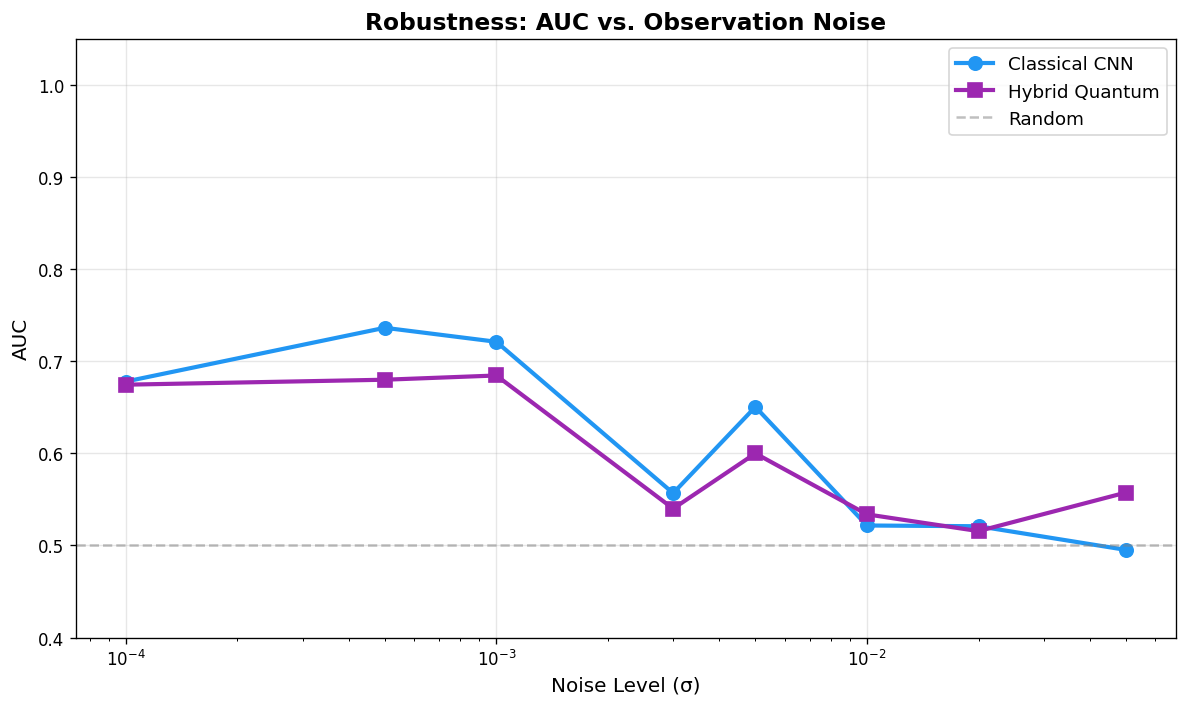

In [23]:

fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

ax.semilogx(stress_results['noise'], stress_results['auc_cnn'],
            'o-', color='#2196F3', linewidth=2.5, markersize=8, label='Classical CNN')
ax.semilogx(stress_results['noise'], stress_results['auc_hybrid'],
            's-', color='#9C27B0', linewidth=2.5, markersize=8, label='Hybrid Quantum')

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
ax.set_xlabel('Noise Level (σ)', fontsize=12)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Robustness: AUC vs. Observation Noise', fontsize=14, weight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim([0.4, 1.05])

plt.tight_layout()
plt.savefig('robustness_noise.png', dpi=150, bbox_inches='tight')
plt.show()

## Inference


In [24]:

def preprocess_lightcurve(flux, n_points=N_POINTS):
    """Preprocess a raw light curve for model inference."""
    flux = np.array(flux, dtype=np.float32)
    
    # Resample to expected length if needed
    if len(flux) != n_points:
        from scipy.interpolate import interp1d
        x_old = np.linspace(0, 1, len(flux))
        x_new = np.linspace(0, 1, n_points)
        f = interp1d(x_old, flux, kind='linear')
        flux = f(x_new).astype(np.float32)
    
    # Same normalization as training: divide by median, subtract 1
    baseline = np.median(flux)
    if baseline > 0:
        flux = flux / baseline
    flux = flux - 1.0
    
    # To tensor: (1, 1, n_points)
    return torch.tensor(flux).unsqueeze(0).unsqueeze(0)


def predict_transit(flux, model=None, model_name='cnn', threshold=0.5):
    """Run inference on a single light curve."""
    if model is None:
        model = model_cnn if model_name == 'cnn' else model_hybrid
    
    device = 'cpu' if model_name == 'hybrid' else DEVICE
    model = model.to(device)
    model.eval()
    
    x = preprocess_lightcurve(flux).to(device)
    
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    
    pred = int(probs[1] >= threshold)
    return {
        'prediction': pred,
        'label': 'TRANSIT' if pred == 1 else 'NO TRANSIT',
        'probability_transit': float(probs[1]),
        'probability_no_transit': float(probs[0]),
        'confidence': float(max(probs)),
    }


def batch_inference(flux_list, model_name='cnn'):
    """Run inference on a batch of light curves."""
    return [predict_transit(f, model_name=model_name) for f in flux_list]


print('Inference pipeline ready.')
print('  result = predict_transit(flux_array, model_name="cnn")')
print('  results = batch_inference([flux1, flux2, ...], model_name="hybrid")')


Inference pipeline ready.
  result = predict_transit(flux_array, model_name="cnn")
  results = batch_inference([flux1, flux2, ...], model_name="hybrid")


INFERENCE DEMO


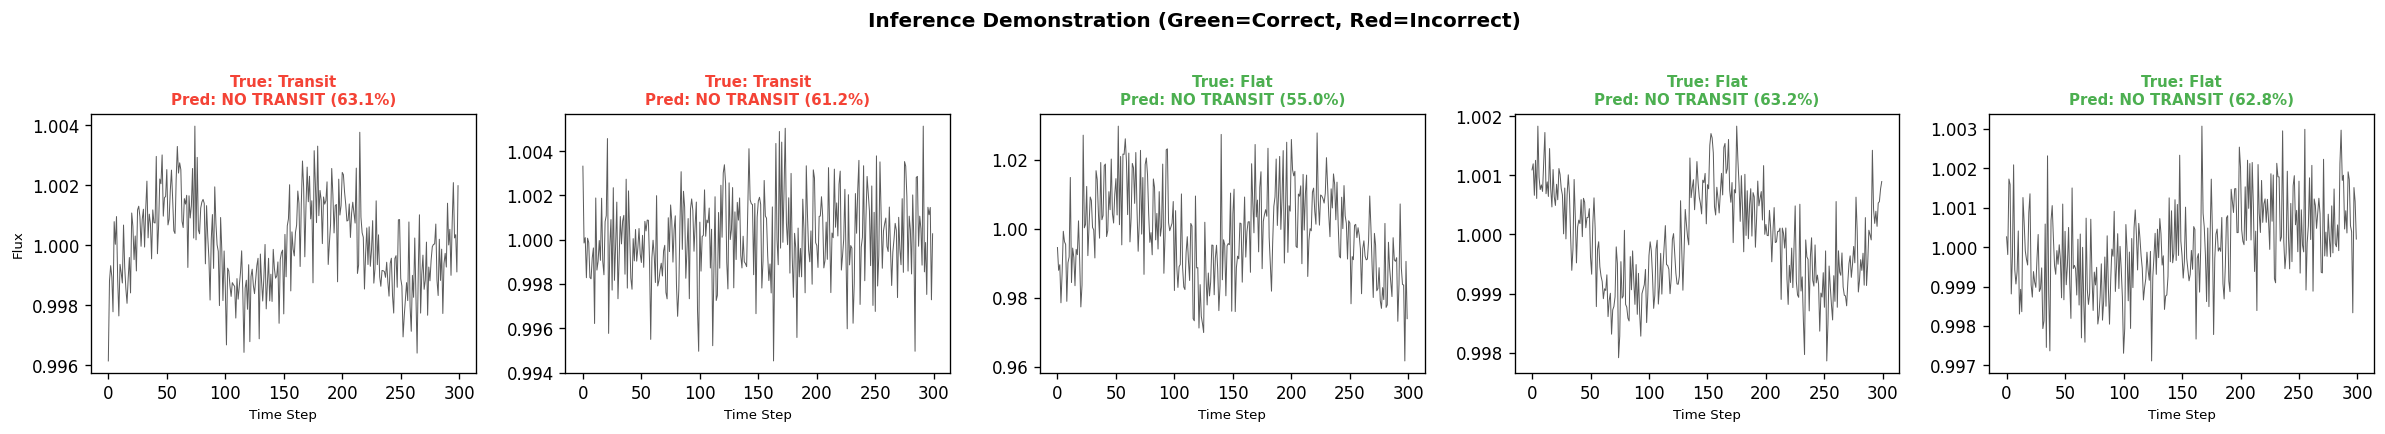

In [25]:

print("=" * 60)
print("INFERENCE DEMO")
print("=" * 60)

# Test on a few examples from the test set
demo_indices = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(1, len(demo_indices), figsize=(20, 3.5), dpi=120)

for i, idx in enumerate(demo_indices):
    flux_raw = X_all[idx]  # Use un-normalised data
    true_label = y_all[idx]
    
    # CNN prediction
    result = predict_transit(flux_raw, model_name='cnn')
    
    ax = axes[i]
    color = '#4CAF50' if result['prediction'] == true_label else '#F44336'
    ax.plot(flux_raw, linewidth=0.6, color='#333333', alpha=0.8)
    ax.set_title(
        f"True: {'Transit' if true_label else 'Flat'}\n"
        f"Pred: {result['label']} ({result['confidence']:.1%})",
        fontsize=9, color=color, weight='bold'
    )
    ax.set_xlabel('Time Step', fontsize=8)
    if i == 0:
        ax.set_ylabel('Flux', fontsize=8)

plt.suptitle('Inference Demonstration (Green=Correct, Red=Incorrect)',
             fontsize=12, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig('inference_demo.png', dpi=150, bbox_inches='tight')
plt.show()

## Export


In [26]:

# Save models
torch.save(model_cnn.state_dict(), 'best_transit_cnn.pt')
torch.save(model_hybrid.state_dict(), 'best_hybrid_quantum.pt')

# Save results summary
summary = {
    'task': 'EXXA4 Sequential Test — Transit Light Curve Classification',
    'author': 'Abdellah Elmlih',
    'dataset': {
        'total_samples': int(N_SAMPLES),
        'time_steps': int(N_POINTS),
        'train_samples': int(len(X_train)),
        'val_samples': int(len(X_val)),
        'test_samples': int(len(X_test)),
        'noise_levels': NOISE_LEVELS,
        'transit_model': 'batman (Mandel & Agol 2002, quadratic limb darkening)',
        'physical_params': list(PARAM_RANGES.keys()),
    },
    'classical_cnn': {
        'architecture': 'ResBlock1D-CNN with GELU + Cosine Annealing',
        'parameters': int(n_params),
        'epochs': int(N_EPOCHS_CNN),
        'test_auc': float(auc_cnn),
        'test_ap': float(ap_cnn),
        'test_accuracy': float(np.mean(preds_cnn == labels_test)),
    },
    'hybrid_quantum': {
        'architecture': 'Classical backbone + VQC (angle encoding + CNOT ring)',
        'n_qubits': int(N_QUBITS),
        'n_qlayers': int(N_QLAYERS),
        'parameters': int(n_params_h),
        'epochs': int(N_EPOCHS_Q),
        'training_samples': int(N_QUANTUM_TRAIN),
        'test_auc': float(auc_hyb),
        'test_ap': float(ap_hyb),
        'test_accuracy': float(np.mean(preds_hybrid == labels_test)),
    },
}

with open('results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print("  best_transit_cnn.pt       — Classical CNN weights")
print("  best_hybrid_quantum.pt    — Hybrid quantum weights")
print("  results_summary.json      — Full results metadata")
print("\n" + "=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(json.dumps(summary, indent=2))

Saved:
  best_transit_cnn.pt       — Classical CNN weights
  best_hybrid_quantum.pt    — Hybrid quantum weights
  results_summary.json      — Full results metadata

FINAL RESULTS SUMMARY
{
  "task": "EXXA4 Sequential Test \u2014 Transit Light Curve Classification",
  "author": "Abdellah Elmlih",
  "dataset": {
    "total_samples": 6000,
    "time_steps": 300,
    "train_samples": 4200,
    "val_samples": 900,
    "test_samples": 900,
    "noise_levels": [
      0.0005,
      0.001,
      0.002,
      0.005,
      0.01
    ],
    "transit_model": "batman (Mandel & Agol 2002, quadratic limb darkening)",
    "physical_params": [
      "rp_rs",
      "a_rs",
      "inc",
      "ecc",
      "omega",
      "period",
      "u1",
      "u2"
    ]
  },
  "classical_cnn": {
    "architecture": "ResBlock1D-CNN with GELU + Cosine Annealing",
    "parameters": 194946,
    "epochs": 40,
    "test_auc": 0.6334271604938272,
    "test_ap": 0.7074964112435131,
    "test_accuracy": 0.6211111111111111
  }

## References

- Mandel & Agol (2002) — transit model
- Kreidberg (2015) — batman package
- Ciliberto et al. (2018) — quantum ML
